<div style=BLUE: #EDF4FA; padding: 50px 40px; border-radius: 12px; text-align: center; font-family: 'Open Sans', sans-serif;">
<!-- ✅ UNIVERSITY LOGO — replace src with your logo URL or base64 -->
  <img src="https://cdn.remotexs.co/institute-logos/uz.png"
       alt="University Logo"
       style="height:300px; width:300px; margin-bottom:18px; display:block; margin-left:auto; margin-right:auto;">

<h1 style="color: BLACK; font-size: 2.8em; letter-spacing: 2px; margin-bottom: 5px; text-shadow: 2px 2px 4px rgba(0,0,0,0.1);">APPLICATION OF TIME SERIES </h1>
<h2 style="color: black; font-size: 2em; font-weight: 300; margin-top: 0; opacity: 0.9;">Practices Handbook</h2>
<h3 style="color: #555555; font-size: 1.2em; font-weight: normal; letter-spacing: 1px; margin-top: 10px;"></h3>



<table style="margin: 0 auto; color: black; font-size: 1.1em; border: none; background: rgba(0,0,0,0.05); border-radius: 8px; padding: 10px;">
  <tr><td style="padding: 8px 25px; text-align: right; color: #555555; font-weight: bold;">Student Name:</td><td style="padding: 8px 15px; color: black; font-weight: bold;">Liberty Nhondoro</td></tr>
  <tr><td style="padding: 8px 25px; text-align: right; color: #555555; font-weight: bold;">Registration Number:</td><td style="padding: 8px 15px; color: black;">R2424989</td></tr>
  <tr><td style="padding: 8px 25px; text-align: right; color: #555555; font-weight: bold;">Course Code:</td><td style="padding: 8px 15px; color: black;">HAST211</td></tr>
  <tr><td style="padding: 8px 25px; text-align: right; color: #555555; font-weight: bold;">Assignment:</td><td style="padding: 8px 15px; color: black;">Assignment 1</td></tr>
  <tr><td style="padding: 8px 25px; text-align: right; color: #555555; font-weight: bold;">Asset:</td><td style="padding: 8px 15px; color: black;">Apple Inc. (AAPL) - Yahoo Finance via <code style="color:#e94560;">yfinance</code></td></tr>
  <tr><td style="padding: 8px 25px; text-align: right; color: #555555; font-weight: bold;">Period:</td><td style="padding: 8px 15px; color: black;">January 2018 - December 2025</td></tr>
</table>



<h3 style="color: black; font-size: 1.2em; margin-bottom: 15px; text-shadow:
</div>

<hr style="border: 1px solid #e94560; margin: 30px auto; width: 65%;"/>

<div style="background: rgba(0,0,0,0.05); padding: 15px 25px; border-radius: 6px; color: black; font-style: italic;">
</div>

</div>

# FINANCIAL ECONOMETRICS — Project #1
## Best-Practices Handbook: Time Series Modeling Challenges

**Scenario:** As newly hired quants on the derivatives desk, we are tasked with modeling volatility for traders and risk managers. This handbook addresses four key challenges in time series modeling using Apple Inc. (AAPL) historical stock data.

**Challenges Covered:**
1. Multicollinearity
2. Skewness
3. Sensitivity to Outliers
4. Overfitting

---

## Setup & Data Download
We download Apple Inc. (AAPL) daily stock data from Yahoo Finance using the `yfinance` API covering **January 1, 2018 – December 31, 2025**.

In [1]:
# ── Install dependencies (run once if needed) ──────────────────────────────
# !pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels scikit-learn

import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera, kurtosis, skew
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import OLS
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
import itertools

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})
COLORS = ['#2c7bb6', '#d7191c', '#1a9641', '#fdae61', '#762a83']

# ── Download AAPL data ──────────────────────────────────────────────────────
START = '2018-01-01'
END   = '2025-12-31'
TICKER = 'AAPL'

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
raw.columns = raw.columns.get_level_values(0) if isinstance(raw.columns, pd.MultiIndex) else raw.columns
raw.index = pd.to_datetime(raw.index)

print(f"Downloaded {len(raw):,} trading days of {TICKER} data")
print(f"Date range: {raw.index.min().date()} → {raw.index.max().date()}")
print()
raw.tail()

[*********************100%***********************]  1 of 1 completed

Downloaded 2,010 trading days of AAPL data
Date range: 2018-01-02 → 2025-12-30



Price,Close,High,Low,Open,Volume
Date,,,,,
2025-12-23,272.105377,272.245261,269.308007,270.586809,29642000
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800
2025-12-29,273.504089,274.103504,272.095404,272.435082,23715200
2025-12-30,272.824707,273.823772,272.025467,272.554970,22139600


In [2]:
# ── Feature engineering ─────────────────────────────────────────────────────
df = raw.copy()

# Log returns
df['Log_Return']     = np.log(df['Close'] / df['Close'].shift(1))

# Lagged returns
for lag in [1, 2, 3, 5]:
    df[f'Ret_Lag{lag}'] = df['Log_Return'].shift(lag)

# Rolling volatility windows
for w in [5, 10, 20, 30, 60]:
    df[f'Vol_{w}d']  = df['Log_Return'].rolling(w).std() * np.sqrt(252)

# Technical features
df['MA_5']          = df['Close'].rolling(5).mean()
df['MA_20']         = df['Close'].rolling(20).mean()
df['MA_60']         = df['Close'].rolling(60).mean()
df['Price_Range']   = (df['High'] - df['Low']) / df['Close']  # normalised daily range
df['Volume_MA20']   = df['Volume'].rolling(20).mean()
df['Vol_Ratio']     = df['Volume'] / df['Volume_MA20']        # volume surge
df['RSI_14']        = 100 - 100 / (1 + (
                        df['Log_Return'].clip(lower=0).rolling(14).mean() /
                        (-df['Log_Return'].clip(upper=0)).rolling(14).mean()
                      ))

df.dropna(inplace=True)
print(f"Working dataset: {len(df):,} rows × {df.shape[1]} columns")
print(df.describe().round(4))

Working dataset: 1,950 rows × 22 columns
Price      Close       High        Low       Open        Volume  Log_Return  \
count  1950.0000  1950.0000  1950.0000  1950.0000  1.950000e+03   1950.0000   
mean    138.2427   139.6374   136.7060   138.1068  9.272538e+07      0.0010   
std      65.5734    66.1394    64.9406    65.5101  5.353159e+07      0.0194   
min      33.7681    34.6064    33.7230    34.1932  1.791060e+07     -0.1377   
25%      70.7979    72.3246    69.5075    70.3365  5.492935e+07     -0.0078   
50%     144.5835   145.7681   142.6510   144.2939  7.928030e+07      0.0013   
75%     184.5593   185.8859   182.4199   184.3921  1.123920e+08      0.0111   
max     285.9225   288.3502   283.0352   285.9325  4.265100e+08      0.1426   

Price   Ret_Lag1   Ret_Lag2   Ret_Lag3   Ret_Lag5  ...    Vol_20d    Vol_30d  \
count  1950.0000  1950.0000  1950.0000  1950.0000  ...  1950.0000  1950.0000   
mean      0.0010     0.0010     0.0010     0.0010  ...     0.2793     0.2827   
std    

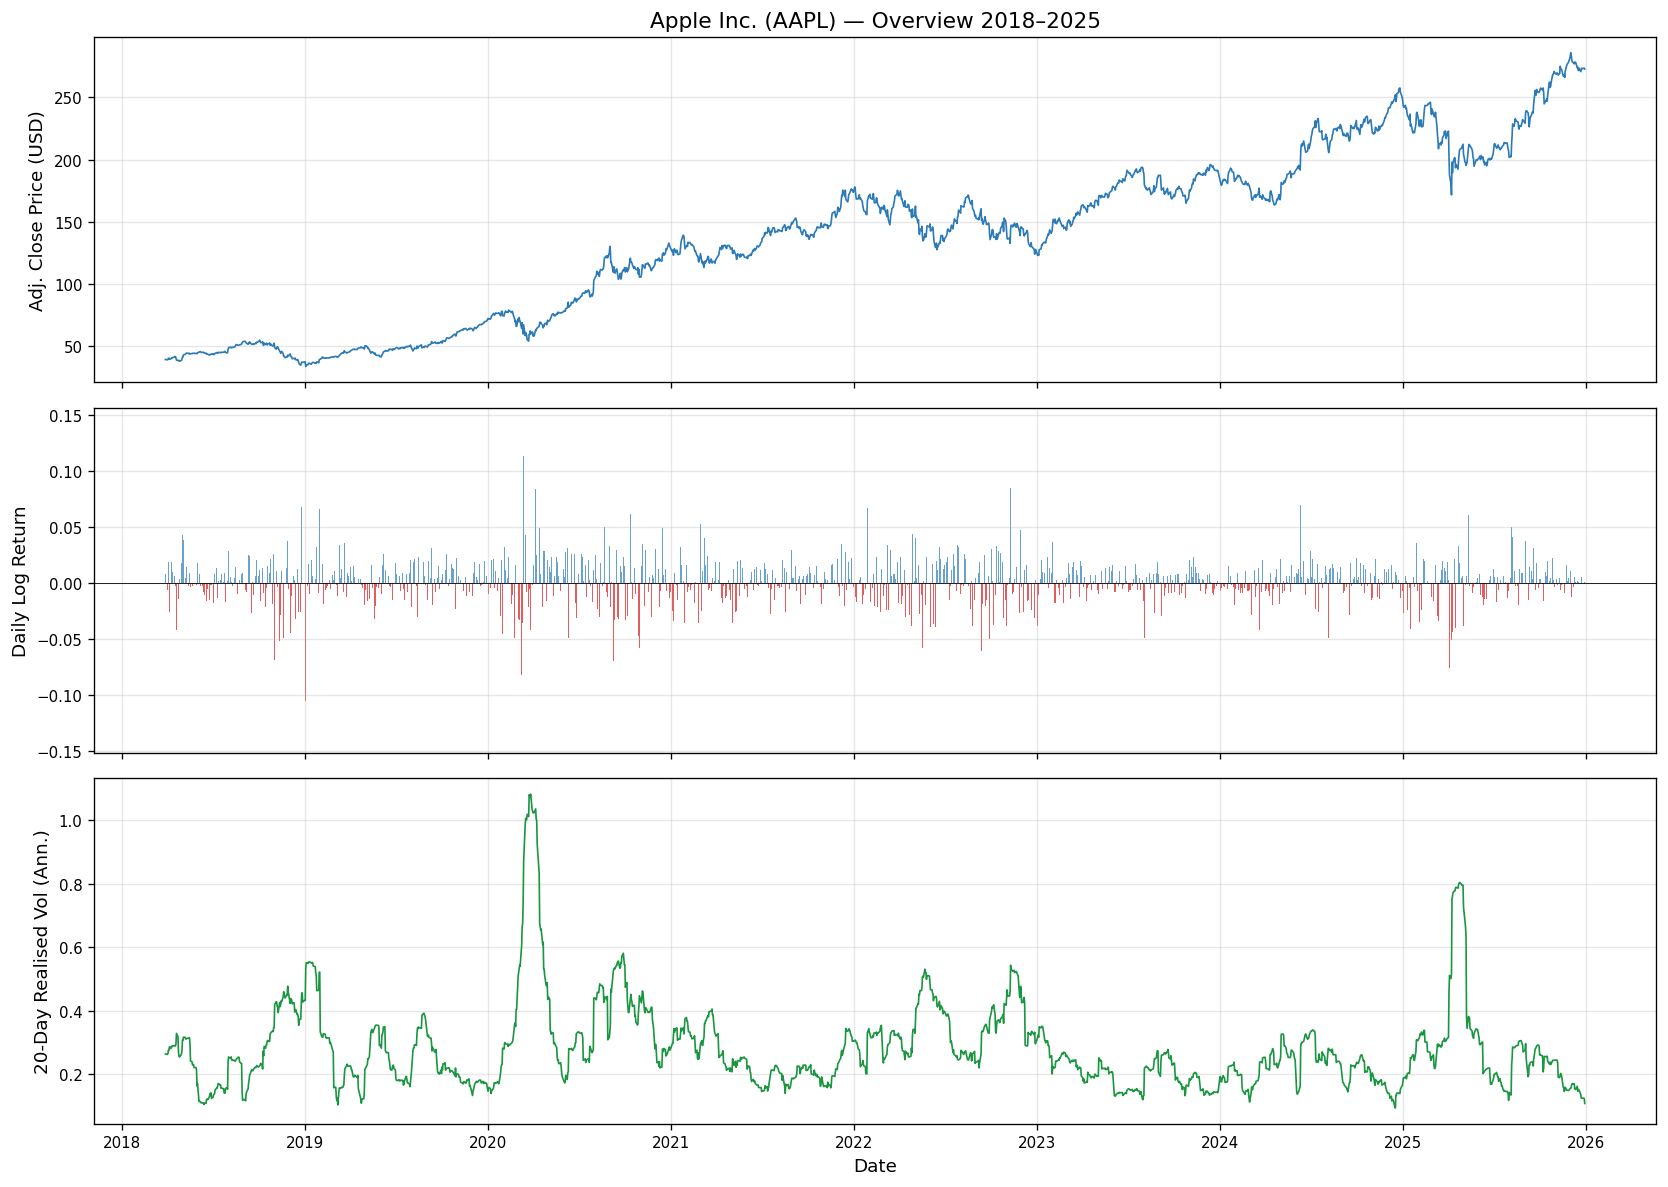

Figure saved: aapl_overview.png


In [3]:
# ── Quick overview chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['Close'], color=COLORS[0], linewidth=1)
axes[0].set_ylabel('Adj. Close Price (USD)')
axes[0].set_title('Apple Inc. (AAPL) — Overview 2018–2025')

axes[1].bar(df.index, df['Log_Return'], color=np.where(df['Log_Return'] >= 0, COLORS[0], COLORS[1]),
            width=1, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Daily Log Return')

axes[2].plot(df.index, df['Vol_20d'], color=COLORS[2], linewidth=1)
axes[2].set_ylabel('20-Day Realised Vol (Ann.)')
axes[2].set_xlabel('Date')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('aapl_overview.png', bbox_inches='tight')
plt.show()
print("Figure saved: aapl_overview.png")

---
# Challenge 1 — MULTICOLLINEARITY
---

### 1.1 Definition

Multicollinearity occurs when two or more predictor variables $x_i$ and $x_j$ in a regression model are highly correlated, i.e.:

$$\rho(x_i, x_j) = \frac{\text{Cov}(x_i, x_j)}{\sigma_{x_i}\sigma_{x_j}} \approx \pm 1$$

It is formally detected via the **Variance Inflation Factor (VIF)**:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ is the coefficient of determination from regressing predictor $x_j$ on all other predictors. A VIF $> 10$ (or conservatively $> 5$) signals problematic multicollinearity.

### 1.2 Description

Multicollinearity is the condition in which independent variables in a regression model are so strongly intercorrelated that the model cannot reliably isolate the individual effect of each predictor. In volatility modelling, this frequently arises when multiple moving-average or rolling-window features are derived from the same price series, inflating standard errors and making coefficient estimates unstable.

### 1.3 Demonstration — Numerical Example

In [4]:
# Question 1 — Multicollinearity Demonstration

# Select correlated predictors (all derived from the same AAPL Close price)
mc_features = ['MA_5', 'MA_20', 'MA_60', 'Vol_5d', 'Vol_10d', 'Vol_20d', 'Vol_30d', 'Vol_60d']
mc_df = df[mc_features].dropna()

# ── Correlation matrix ───────────────────────────────────────────────────────
corr = mc_df.corr().round(4)
print("Correlation Matrix:")
print(corr)

print("\nVIF Scores:")
X_mc = sm.add_constant(mc_df)
vif_data = pd.DataFrame()
vif_data['Feature'] = mc_df.columns
vif_data['VIF']     = [variance_inflation_factor(X_mc.values, i+1) for i in range(len(mc_df.columns))]
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

Correlation Matrix:
Price      MA_5   MA_20   MA_60  Vol_5d  Vol_10d  Vol_20d  Vol_30d  Vol_60d
Price                                                                      
MA_5     1.0000  0.9973  0.9888 -0.1755  -0.1858  -0.1985  -0.2102  -0.2470
MA_20    0.9973  1.0000  0.9941 -0.1532  -0.1647  -0.1846  -0.1993  -0.2420
MA_60    0.9888  0.9941  1.0000 -0.1295  -0.1324  -0.1432  -0.1563  -0.2084
Vol_5d  -0.1755 -0.1532 -0.1295  1.0000   0.8557   0.7118   0.6360   0.4468
Vol_10d -0.1858 -0.1647 -0.1324  0.8557   1.0000   0.8632   0.7775   0.5558
Vol_20d -0.1985 -0.1846 -0.1432  0.7118   0.8632   1.0000   0.9276   0.7016
Vol_30d -0.2102 -0.1993 -0.1563  0.6360   0.7775   0.9276   1.0000   0.8131
Vol_60d -0.2470 -0.2420 -0.2084  0.4468   0.5558   0.7016   0.8131   1.0000

VIF Scores:
Feature        VIF
  MA_20 462.652883
   MA_5 237.824260
  MA_60 115.131050
Vol_20d  11.663503
Vol_30d  11.581620
Vol_10d   7.491738
 Vol_5d   3.850842
Vol_60d   3.228764


### 1.4 Diagram — Visual Example

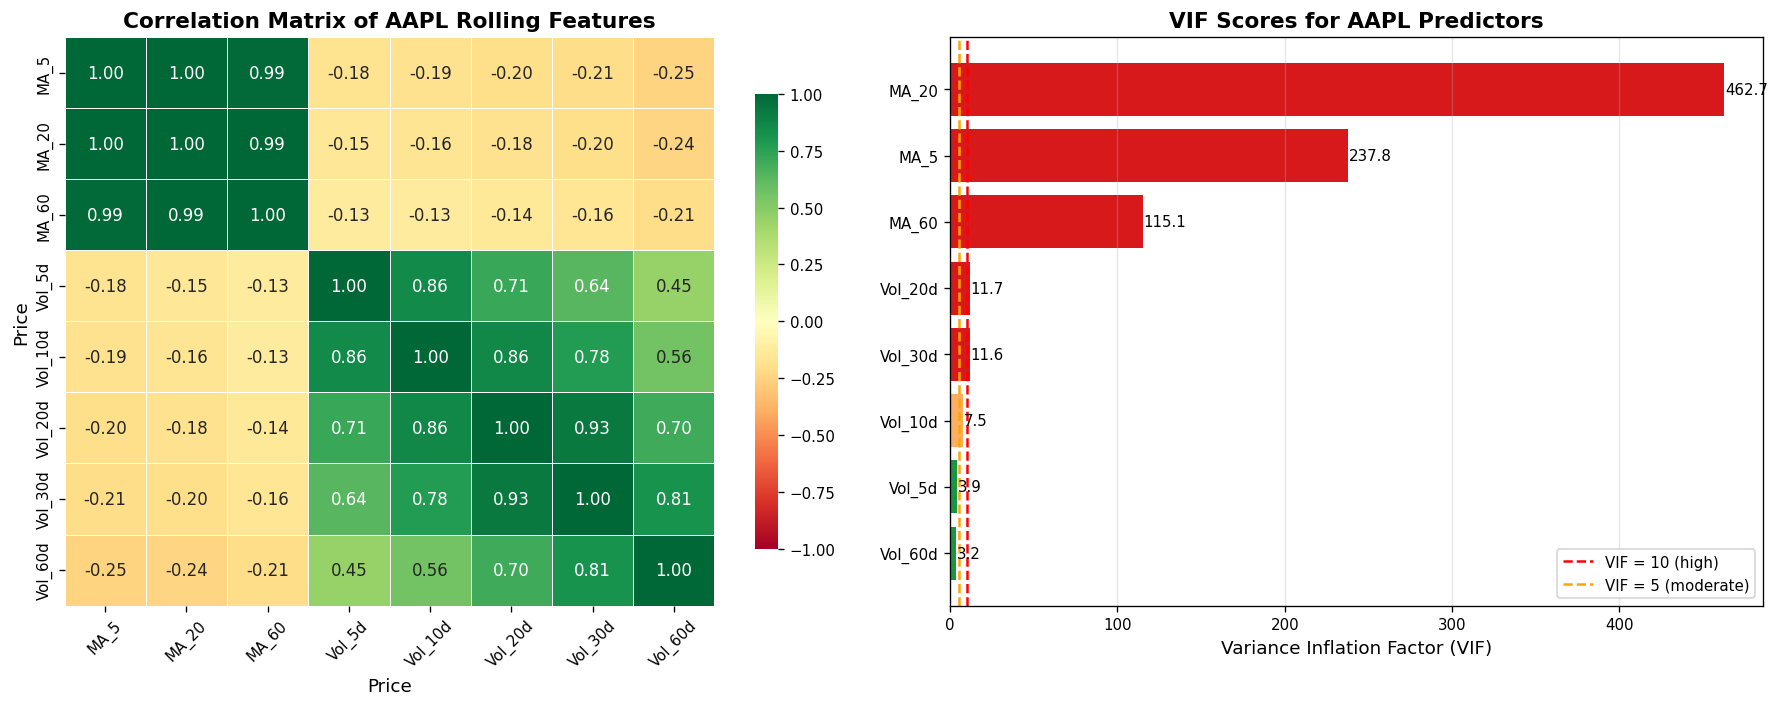

Figure saved: multicollinearity_diagram.png


In [5]:
# Question 1 — Multicollinearity Diagram
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Correlation heatmap
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Matrix of AAPL Rolling Features', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Panel B: VIF bar chart
vif_sorted = vif_data.sort_values('VIF', ascending=True)
colors_vif = ['#d7191c' if v > 10 else '#fdae61' if v > 5 else '#1a9641'
              for v in vif_sorted['VIF']]
bars = axes[1].barh(vif_sorted['Feature'], vif_sorted['VIF'], color=colors_vif)
axes[1].axvline(10, color='red', linestyle='--', label='VIF = 10 (high)')
axes[1].axvline(5,  color='orange', linestyle='--', label='VIF = 5 (moderate)')
axes[1].set_xlabel('Variance Inflation Factor (VIF)')
axes[1].set_title('VIF Scores for AAPL Predictors', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

for bar, val in zip(bars, vif_sorted['VIF']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('multicollinearity_diagram.png', bbox_inches='tight')
plt.show()
print("Figure saved: multicollinearity_diagram.png")

### 1.5 Diagnosis — How to Detect Multicollinearity

| Test | Threshold | Interpretation |
|---|---|---|
| Pearson Correlation $\|\rho\| > 0.90$ | — | Near-perfect linear dependence |
| VIF $> 5$ | Moderate concern | Coefficients becoming unreliable |
| VIF $> 10$ | Severe concern | Estimates are essentially meaningless |
| Condition Number $> 30$ | — | Severe ill-conditioning of design matrix |
| Eigenvalue near zero | — | Indicates near-singular design matrix |

In [6]:
# Question 1 — Diagnosis: Condition Number
X_scaled = StandardScaler().fit_transform(mc_df)
eigenvalues = np.linalg.eigvals(np.corrcoef(X_scaled.T))
condition_number = np.sqrt(eigenvalues.max() / eigenvalues.min())
print(f"Condition Number of feature matrix: {condition_number:.2f}")
print("Interpretation: Values > 30 indicate severe multicollinearity.")
print(f"\nEigenvalues: {np.sort(eigenvalues.real)[::-1].round(3)}")

Condition Number of feature matrix: 55.45
Interpretation: Values > 30 indicate severe multicollinearity.

Eigenvalues: [4.310e+00 2.624e+00 6.770e-01 2.320e-01 9.900e-02 4.700e-02 1.000e-02
 1.000e-03]


### 1.6 Damage — Consequences of Multicollinearity

- **Inflated standard errors**: OLS coefficient estimates $\hat{\beta}$ become highly imprecise, making individual hypothesis tests ($t$-statistics) unreliable even when $R^2$ is high.
- **Sign reversals**: Regression coefficients may flip sign between samples, producing economically nonsensical interpretations (e.g., a positive coefficient for a risk factor that should be negative).
- **Unstable pricing models**: In derivatives pricing, unstable factor exposures lead to incorrect delta/vega hedges and mispricings, resulting in direct P&L losses.
- **Model fragility**: Small changes in the sample period or slight data revisions cause drastic changes in estimated parameters.

### 1.7 Directions — Remediation Methods

| Method | How it helps |
|---|---|
| **Remove redundant features** | Drop one of a highly correlated pair (e.g., keep MA_20, drop MA_5 and MA_60) |
| **Ridge Regression (L2)** | Adds penalty $\lambda\|\beta\|^2_2$ to shrink coefficients without eliminating them |
| **Lasso Regression (L1)** | Adds penalty $\lambda\|\beta\|_1$, performs automatic variable selection |
| **Principal Component Analysis (PCA)** | Decorrelates features by projecting onto orthogonal axes |
| **Partial Least Squares (PLS)** | Finds directions that maximise covariance between X and y |

In [7]:
# Question 1 — Directions: OLS vs Ridge vs Lasso comparison
target_col = 'Vol_20d'
pred_cols  = ['MA_5', 'MA_20', 'MA_60', 'Vol_5d', 'Vol_10d', 'Vol_30d', 'Vol_60d']

X = df[pred_cols].values
y = df[target_col].values
X_s = StandardScaler().fit_transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(X_s, y, test_size=0.2, shuffle=False)

results = {}
for name, model in [('OLS', LinearRegression()),
                     ('Ridge (λ=1)', Ridge(alpha=1.0)),
                     ('Lasso (λ=0.001)', Lasso(alpha=0.001))]:
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    results[name] = {'Coefficients': model.coef_, 'RMSE': rmse}
    print(f"\n{name} — Test RMSE: {rmse:.5f}")
    print(pd.Series(model.coef_, index=pred_cols).round(5).to_string())

print("\n→ Ridge/Lasso produce smaller, more stable coefficients than OLS.")


OLS — Test RMSE: 0.05394
MA_5      -0.00439
MA_20     -0.01103
MA_60      0.01444
Vol_5d    -0.00143
Vol_10d    0.05000
Vol_30d    0.09684
Vol_60d   -0.01114

Ridge (λ=1) — Test RMSE: 0.05397
MA_5      -0.00570
MA_20     -0.00809
MA_60      0.01283
Vol_5d    -0.00134
Vol_10d    0.04997
Vol_30d    0.09663
Vol_60d   -0.01094

Lasso (λ=0.001) — Test RMSE: 0.05403
MA_5      -0.00000
MA_20     -0.00000
MA_60      0.00000
Vol_5d     0.00000
Vol_10d    0.04941
Vol_30d    0.09127
Vol_60d   -0.00545

→ Ridge/Lasso produce smaller, more stable coefficients than OLS.


---
# Challenge 2 — SKEWNESS
---

### 2.1 Definition

Skewness measures the asymmetry of a probability distribution $X$ relative to its mean $\mu$:

$$\text{Skewness} = \frac{E\left[(X-\mu)^3\right]}{\sigma^3} = \frac{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^3}{\left[\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2\right]^{3/2}}$$

A symmetric distribution has skewness $= 0$. **Negative (left) skewness** ($< 0$) indicates a longer left tail, meaning large negative returns occur more frequently than a Normal distribution would predict — this is the empirically observed property of financial asset returns known as **negative skewness** or **fat-tailed crash risk**.

### 2.2 Description

Skewness in financial return series means the distribution is asymmetric around its mean, violating the normality assumption central to most classical models (Black-Scholes, standard VaR). In practice, equity returns exhibit **negative skewness** — sudden large drawdowns are more common than equivalent large gains — which causes standard models to underprice downside risk and out-of-the-money put options.

### 2.3 Demonstration — Numerical Example

In [8]:
# Question 2 — Skewness Demonstration
ret = df['Log_Return'].dropna()

sk   = skew(ret)
kurt = kurtosis(ret, fisher=True)   # excess kurtosis (Normal = 0)
jb_stat, jb_pval = jarque_bera(ret)

print("=" * 50)
print("AAPL Daily Log-Return Distribution Statistics")
print("=" * 50)
print(f"Observations  : {len(ret):,}")
print(f"Mean          : {ret.mean():.6f}")
print(f"Std Dev       : {ret.std():.6f}")
print(f"Skewness      : {sk:.4f}  (Normal = 0)")
print(f"Excess Kurtosis: {kurt:.4f} (Normal = 0)")
print(f"Jarque-Bera   : {jb_stat:.2f}, p-value = {jb_pval:.2e}")
print()
if sk < 0:
    print(f"→ Negative skewness ({sk:.4f}): AAPL returns have a longer LEFT tail.")
    print("  Large negative return days occur more often than a Normal model predicts.")

# Annual breakdown
print("\nSkewness by year:")
annual = df['Log_Return'].groupby(df.index.year).agg(skew)
print(annual.rename('Skewness').to_string())

AAPL Daily Log-Return Distribution Statistics
Observations  : 1,950
Mean          : 0.000996
Std Dev       : 0.019448
Skewness      : -0.0967  (Normal = 0)
Excess Kurtosis: 6.2821 (Normal = 0)
Jarque-Bera   : 3209.60, p-value = 0.00e+00

→ Negative skewness (-0.0967): AAPL returns have a longer LEFT tail.
  Large negative return days occur more often than a Normal model predicts.

Skewness by year:
Date
2018   -0.269673
2019   -1.128368
2020   -0.308176
2021   -0.126146
2022    0.219091
2023   -0.134091
2024    0.332566
2025    0.704522


### 2.4 Diagram — Visual Example

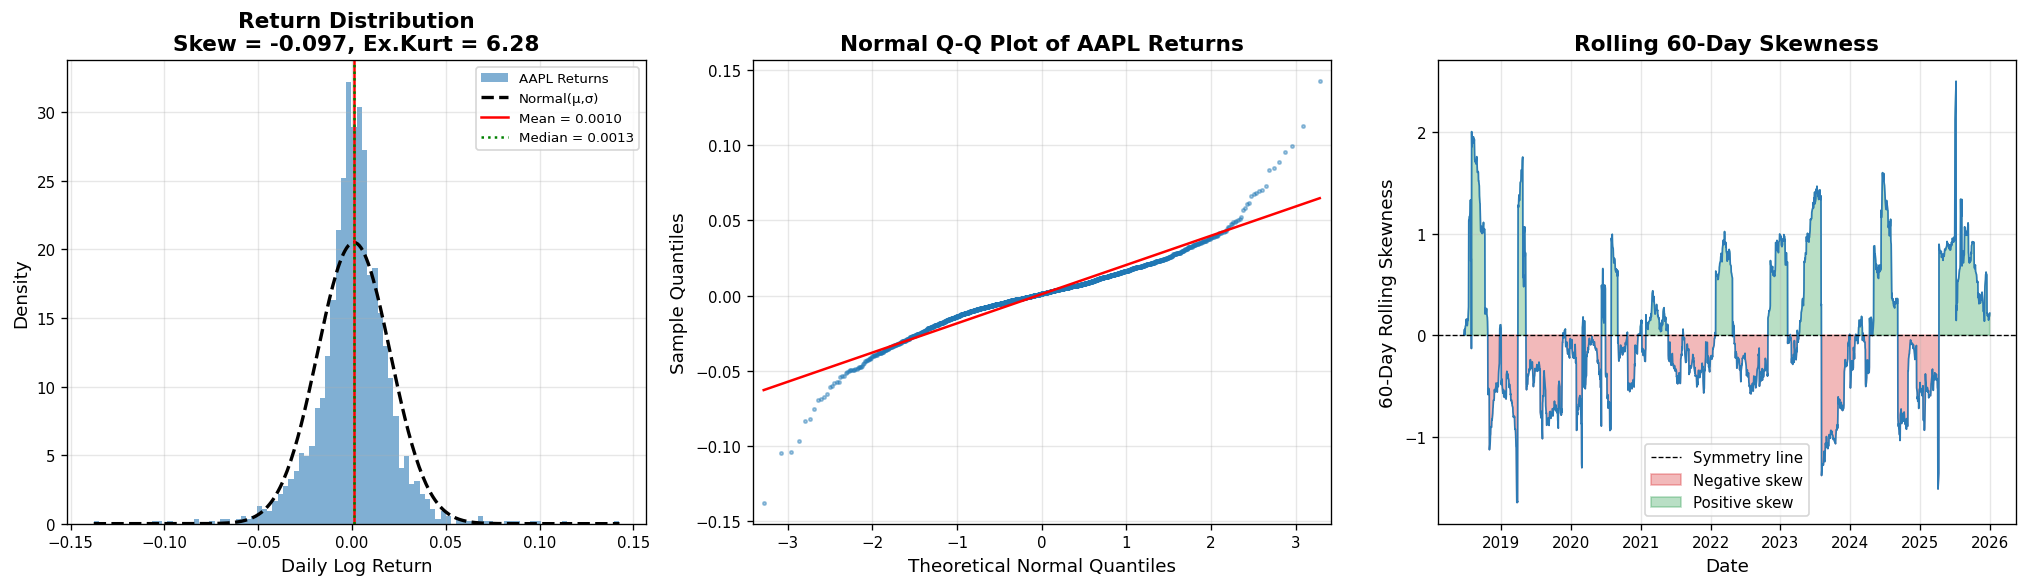

Figure saved: skewness_diagram.png


In [9]:
# Question 2 — Skewness Diagram
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel A: Return histogram vs Normal
ax = axes[0]
mu, sigma = ret.mean(), ret.std()
ax.hist(ret, bins=100, density=True, color=COLORS[0], alpha=0.6, label='AAPL Returns')
x_range = np.linspace(ret.min(), ret.max(), 300)
ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
        color='black', linewidth=2, linestyle='--', label=f'Normal(μ,σ)')
ax.axvline(mu, color='red', linewidth=1.5, label=f'Mean = {mu:.4f}')
ax.axvline(np.median(ret), color='green', linewidth=1.5,
           linestyle=':', label=f'Median = {np.median(ret):.4f}')
ax.set_xlabel('Daily Log Return')
ax.set_ylabel('Density')
ax.set_title(f'Return Distribution\nSkew = {sk:.3f}, Ex.Kurt = {kurt:.2f}', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel B: Q-Q plot
ax = axes[1]
sm.qqplot(ret, line='s', ax=ax, alpha=0.4, markersize=2)
ax.set_title('Normal Q-Q Plot of AAPL Returns', fontweight='bold')
ax.set_xlabel('Theoretical Normal Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.grid(True, alpha=0.3)

# Panel C: Rolling skewness over time
ax = axes[2]
rolling_skew = ret.rolling(60).apply(skew)
ax.plot(rolling_skew.index, rolling_skew, color=COLORS[0], linewidth=1)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='Symmetry line')
ax.fill_between(rolling_skew.index, rolling_skew, 0,
                where=(rolling_skew < 0), color=COLORS[1], alpha=0.3, label='Negative skew')
ax.fill_between(rolling_skew.index, rolling_skew, 0,
                where=(rolling_skew >= 0), color=COLORS[2], alpha=0.3, label='Positive skew')
ax.set_xlabel('Date')
ax.set_ylabel('60-Day Rolling Skewness')
ax.set_title('Rolling 60-Day Skewness', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('skewness_diagram.png', bbox_inches='tight')
plt.show()
print("Figure saved: skewness_diagram.png")

### 2.5 Diagnosis — How to Detect Skewness

| Test | Statistic / Rule | Interpretation |
|---|---|---|
| Sample skewness | $< -0.5$ or $> +0.5$ | Moderate; $< -1$ or $> +1$ is severe |
| Jarque-Bera test | $JB = \frac{n}{6}\left(S^2 + \frac{K^2}{4}\right)$ \sim $\chi^2_2$ | $p < 0.05$ rejects normality |
| Q-Q Plot | Deviations from 45° line | S-curve = fat tails; bow = skewness |
| Mean vs Median | $\bar{x} < \tilde{x}$ | Suggests left skew |

### 2.6 Damage — Consequences of Skewness

- **Mispriced options**: Black-Scholes assumes log-normality (skewness $= 0$). Negative skewness causes systematic underpricing of OTM puts and overpricing of OTM calls, generating a persistent *volatility skew/smirk* in the options market.
- **Underestimated VaR/CVaR**: Standard parametric VaR (based on Normal assumption) underestimates the true probability of large losses, leading to insufficient capital reserves.
- **Flawed hedging**: Delta-hedging strategies calibrated on symmetric return distributions fail during crash events, leaving portfolios dangerously exposed.
- **Biased statistical inference**: Hypothesis tests relying on normality (e.g., standard $t$-tests for factor premia) become unreliable.

### 2.7 Directions — Remediation Methods

| Method | Mechanism |
|---|---|
| **Log or Box-Cox transformation** | Reduces right skewness in price levels |
| **Student-t or GED distribution** | Accommodates heavier-than-Normal tails |
| **Skewed-t (Hansen 1994)** | Captures both excess kurtosis and asymmetry |
| **GJR-GARCH / EGARCH** | Asymmetric volatility models capturing leverage effect |
| **Cornish-Fisher expansion** | Adjusts VaR/ES for observed skewness and kurtosis |
| **Extreme Value Theory (EVT)** | Explicitly models tail behaviour using GEV or GPD |

In [10]:
# Question 2 — Directions: Compare Normal vs Student-t VaR
alpha = 0.01  # 99% VaR
mu_r, sig_r = ret.mean(), ret.std()

# Fit Student-t
df_t, loc_t, scale_t = stats.t.fit(ret)

var_normal   = mu_r + sig_r * stats.norm.ppf(alpha)
var_student  = stats.t.ppf(alpha, df=df_t, loc=loc_t, scale=scale_t)
var_empirical = np.quantile(ret, alpha)

print("99% Value-at-Risk Comparison (1-day)")
print("-" * 40)
print(f"Normal VaR   : {var_normal:.4f}  ({var_normal*100:.2f}%)")
print(f"Student-t VaR: {var_student:.4f}  ({var_student*100:.2f}%)")
print(f"Empirical VaR: {var_empirical:.4f}  ({var_empirical*100:.2f}%)")
print()
print(f"→ Normal VaR UNDERESTIMATES tail risk by "
      f"{abs(var_empirical - var_normal)*100:.2f}% vs empirical.")
print(f"  Student-t is {abs(var_empirical - var_student)*100:.3f}% closer to the empirical estimate.")
print(f"  Fitted Student-t degrees of freedom: {df_t:.2f} (Normal → ∞)")

99% Value-at-Risk Comparison (1-day)
----------------------------------------
Normal VaR   : -0.0442  (-4.42%)
Student-t VaR: -0.0530  (-5.30%)
Empirical VaR: -0.0514  (-5.14%)

→ Normal VaR UNDERESTIMATES tail risk by 0.72% vs empirical.
  Student-t is 0.156% closer to the empirical estimate.
  Fitted Student-t degrees of freedom: 3.24 (Normal → ∞)


---
# Challenge 3 — SENSITIVITY TO OUTLIERS
---

### 3.1 Definition

An observation $x_i$ is a statistical outlier if it deviates excessively from the central tendency. Common detection criteria:

**Z-score method:**
$$z_i = \frac{x_i - \bar{x}}{s}, \quad |z_i| > 3 \Rightarrow \text{outlier}$$

**Interquartile Range (IQR) method:**
$$x_i \notin \left[Q_1 - 1.5 \cdot \text{IQR},\; Q_3 + 1.5 \cdot \text{IQR}\right] \Rightarrow \text{outlier}$$

where $\text{IQR} = Q_3 - Q_1$.

**Leverage / Cook's Distance** in regression (influence diagnostics):
$$D_i = \frac{(\hat{\mathbf{y}} - \hat{\mathbf{y}}_{(-i)})^\top (\hat{\mathbf{y}} - \hat{\mathbf{y}}_{(-i)})}{p \cdot s^2}$$

### 3.2 Description

Sensitivity to outliers refers to the degree to which extreme observations disproportionately distort model estimates; OLS regression is particularly vulnerable because it minimises *squared* errors, which amplifies the weight of outlier observations quadratically. In financial time series, outliers correspond to market stress events (crashes, earnings surprises, flash crashes) that, if untreated, corrupt volatility and factor model estimates.

### 3.3 Demonstration — Numerical Example

In [11]:
# Question 3 — Outlier Identification
ret = df['Log_Return'].dropna()

# Z-score method
z_scores = np.abs(stats.zscore(ret))
outliers_z = ret[z_scores > 3]

# IQR method
Q1, Q3 = ret.quantile(0.25), ret.quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ret[(ret < Q1 - 1.5*IQR) | (ret > Q3 + 1.5*IQR)]

print("Outlier Detection Results — AAPL Daily Log Returns")
print("=" * 55)
print(f"Total observations    : {len(ret):,}")
print(f"Z-score (|z|>3) method: {len(outliers_z):,} outliers ({len(outliers_z)/len(ret)*100:.2f}%)")
print(f"IQR fence method      : {len(outliers_iqr):,} outliers ({len(outliers_iqr)/len(ret)*100:.2f}%)")
print()
print("Largest negative outliers (Z-score method):")
print(outliers_z.sort_values().head(10).rename('Log Return').to_frame().assign(
    Date=lambda x: x.index.strftime('%Y-%m-%d'),
    Z_score=lambda x: ((x['Log Return'] - ret.mean()) / ret.std()).round(2)
).to_string())
print()
print(f"Worst single-day return: {ret.min():.4f} on {ret.idxmin().date()}")
print(f"Best  single-day return: {ret.max():.4f} on {ret.idxmax().date()}")

Outlier Detection Results — AAPL Daily Log Returns
Total observations    : 1,950
Z-score (|z|>3) method: 30 outliers (1.54%)
IQR fence method      : 104 outliers (5.33%)

Largest negative outliers (Z-score method):
            Log Return        Date  Z_score
Date                                       
2020-03-16   -0.137708  2020-03-16    -7.13
2019-01-03   -0.104924  2019-01-03    -5.45
2020-03-12   -0.103978  2020-03-12    -5.40
2025-04-03   -0.097013  2025-04-03    -5.04
2020-09-03   -0.083447  2020-09-03    -4.34
2020-03-09   -0.082395  2020-03-09    -4.29
2025-04-04   -0.075680  2025-04-04    -3.94
2020-09-08   -0.069666  2020-09-08    -3.63
2018-11-02   -0.068633  2018-11-02    -3.58
2020-02-27   -0.067602  2020-02-27    -3.53

Worst single-day return: -0.1377 on 2020-03-16
Best  single-day return: 0.1426 on 2025-04-09


In [12]:
# Question 3 — Impact on OLS regression (with vs without outliers)
X_reg = sm.add_constant(df['Ret_Lag1'].loc[ret.index])
y_reg = ret

# OLS with all data
model_full = OLS(y_reg, X_reg).fit()

# OLS excluding Z-score outliers
mask_clean = z_scores <= 3
model_clean = OLS(y_reg[mask_clean], X_reg[mask_clean]).fit()

print("OLS Regression: Today's Return ~ Lag-1 Return")
print("-" * 50)
print(f"{'Parameter':<20} {'Full Sample':>15} {'Outliers Removed':>18}")
print("-" * 55)
for param in ['const', 'Ret_Lag1']:
    full_coef  = model_full.params[param]
    clean_coef = model_clean.params[param]
    print(f"{param:<20} {full_coef:>15.6f} {clean_coef:>18.6f}")
print("-" * 55)
print(f"{'R-squared':<20} {model_full.rsquared:>15.6f} {model_clean.rsquared:>18.6f}")
print(f"{'RMSE':<20} {np.sqrt(model_full.mse_resid):>15.6f} {np.sqrt(model_clean.mse_resid):>18.6f}")
print()
print("→ Outliers inflate RMSE and distort regression coefficients.")

OLS Regression: Today's Return ~ Lag-1 Return
--------------------------------------------------
Parameter                Full Sample   Outliers Removed
-------------------------------------------------------
const                       0.001066           0.000999
Ret_Lag1                   -0.070824          -0.013189
-------------------------------------------------------
R-squared                   0.005017           0.000227
RMSE                        0.019404           0.016537

→ Outliers inflate RMSE and distort regression coefficients.


### 3.4 Diagram — Visual Example

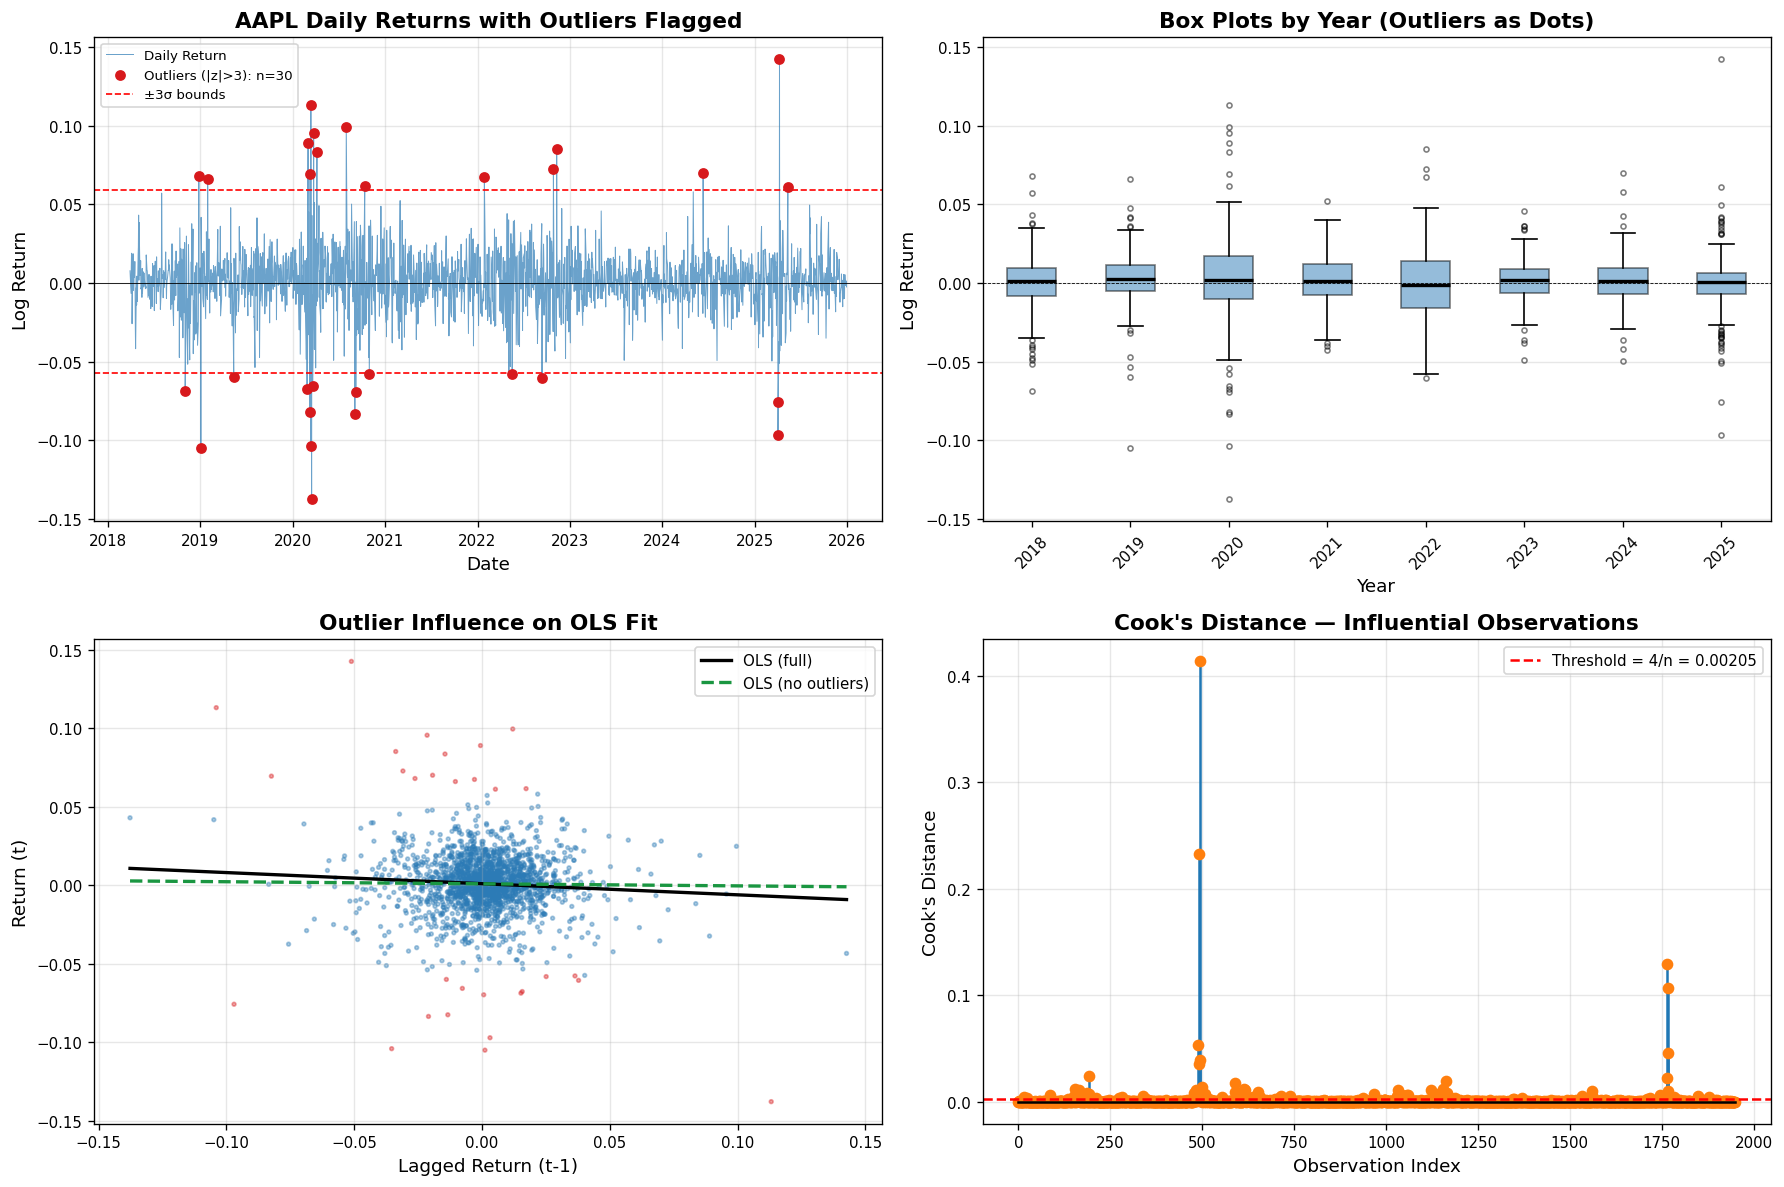

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel A: Time series with outliers highlighted
ax = axes[0, 0]
ax.plot(ret.index, ret, color=COLORS[0], linewidth=0.6, alpha=0.7, label='Daily Return')
ax.scatter(outliers_z.index, outliers_z, color=COLORS[1], s=30, zorder=5,
           label=f'Outliers (|z|>3): n={len(outliers_z)}')
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(ret.mean() + 3*ret.std(), color='red', linestyle='--', linewidth=1, label='±3σ bounds')
ax.axhline(ret.mean() - 3*ret.std(), color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Date'); ax.set_ylabel('Log Return')
ax.set_title('AAPL Daily Returns with Outliers Flagged', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel B: Box plot
ax = axes[0, 1]
years = df.index.year.unique()
data_by_year = [df.loc[df.index.year == y, 'Log_Return'].dropna().values for y in years]
bp = ax.boxplot(data_by_year, labels=years, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', markersize=3, color=COLORS[1], alpha=0.5))
for patch in bp['boxes']:
    patch.set_facecolor(COLORS[0])
    patch.set_alpha(0.5)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_xlabel('Year'); ax.set_ylabel('Log Return')
ax.set_title('Box Plots by Year (Outliers as Dots)', fontweight='bold')
ax.tick_params(axis='x', rotation=45); ax.grid(True, alpha=0.3, axis='y')

# Panel C: OLS regression influence
ax = axes[1, 0]
x_plot = df['Ret_Lag1'].loc[ret.index]
c = np.where(z_scores <= 3, COLORS[0], COLORS[1])
ax.scatter(x_plot, ret, c=c, s=5, alpha=0.4)
x_line = np.linspace(x_plot.min(), x_plot.max(), 100)
ax.plot(x_line, model_full.params['const'] + model_full.params['Ret_Lag1']*x_line,
        color='black', linewidth=2, label='OLS (full)')
ax.plot(x_line, model_clean.params['const'] + model_clean.params['Ret_Lag1']*x_line,
        color=COLORS[2], linewidth=2, linestyle='--', label='OLS (no outliers)')
ax.set_xlabel('Lagged Return (t-1)'); ax.set_ylabel('Return (t)')
ax.set_title('Outlier Influence on OLS Fit', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# Panel D: Cook's Distance
ax = axes[1, 1]
influence = model_full.get_influence()
cooks = influence.cooks_distance[0]
ax.stem(range(len(cooks)), cooks, markerfmt='C1o', linefmt='C0-', basefmt='k-')
threshold = 4 / len(cooks)
ax.axhline(threshold, color='red', linestyle='--', label=f"Threshold = 4/n = {threshold:.5f}")
ax.set_xlabel('Observation Index'); ax.set_ylabel("Cook's Distance")
ax.set_title("Cook's Distance — Influential Observations", fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outlier_diagram.png', bbox_inches='tight')
plt.show()

### 3.5 Diagnosis — How to Detect Outlier Sensitivity

| Diagnostic | Method | Signal |
|---|---|---|
| Z-score | $|z_i| > 3$ | Standard outlier flag |
| IQR fences | $< Q_1 - 1.5 \cdot IQR$ or $> Q_3 + 1.5 \cdot IQR$ | Distribution-free |
| Cook's Distance | $D_i > 4/n$ | Influential regression points |
| DFFITS | $|\text{DFFITS}_i| > 2\sqrt{p/n}$ | Deletion influence on fitted values |
| Grubbs Test | Formal hypothesis test for single outlier | p-value based |
| Box plots | Visual — whisker extensions | Identify distributional extremes |

### 3.6 Damage — Consequences of Outlier Sensitivity

- **Distorted volatility estimates**: A single 10-sigma event day can inflate a rolling volatility estimate for the entire 60-day window, causing options desks to overprice implied volatility long after the event passes.
- **Misspecified regression coefficients**: OLS squares errors, so outliers receive disproportionately large influence on $\hat{\beta}$, potentially reversing the estimated sign of risk factors.
- **VaR model failure**: Stressed returns that are treated as noise inflate sigma estimates, paradoxically making the model appear more conservative when it is actually under-reserving for tail risk.
- **Backtesting contamination**: Strategy backtests trained on crash-period outliers produce unrealistically pessimistic (or optimistic) Sharpe ratios that don't generalise.

### 3.7 Directions — Remediation Methods

In [14]:
# Question 3 — Directions: Robust regression (Huber M-estimator) vs OLS
from statsmodels.robust.robust_linear_model import RLM
import statsmodels.robust.norms as norms

# Robust regression using Huber's M-estimator
model_robust = RLM(y_reg, X_reg, M=norms.HuberT()).fit()

print("Robust (Huber) vs OLS — Comparison")
print("-" * 50)
print(f"{'Parameter':<20} {'OLS':>12} {'Huber M-est.':>15}")
print("-" * 50)
for param in ['const', 'Ret_Lag1']:
    print(f"{param:<20} {model_full.params[param]:>12.6f} {model_robust.params[param]:>15.6f}")

print()
print("Other robust regression methods for financial time series:")
methods = [
    ("Huber M-estimator",   "Downweights large residuals continuously"),
    ("Least Trimmed Squares (LTS)", "Fits to subset of n-k observations ignoring worst outliers"),
    ("Winsorization",       "Cap returns at e.g. 1st/99th percentile before fitting"),
    ("Quantile Regression", "Estimates conditional median instead of mean (outlier-immune)"),
    ("GARCH-t",             "Student-t innovations model fat tails explicitly"),
]
for m, d in methods:
    print(f"  • {m:35s}: {d}")

Robust (Huber) vs OLS — Comparison
--------------------------------------------------
Parameter                     OLS    Huber M-est.
--------------------------------------------------
const                    0.001066        0.001423
Ret_Lag1                -0.070824       -0.029380

Other robust regression methods for financial time series:
  • Huber M-estimator                  : Downweights large residuals continuously
  • Least Trimmed Squares (LTS)        : Fits to subset of n-k observations ignoring worst outliers
  • Winsorization                      : Cap returns at e.g. 1st/99th percentile before fitting
  • Quantile Regression                : Estimates conditional median instead of mean (outlier-immune)
  • GARCH-t                            : Student-t innovations model fat tails explicitly


---
# Challenge 4 — OVERFITTING
---

### 4.1 Definition

Overfitting occurs when a model learns the noise specific to the training sample rather than the true underlying data-generating process. For a model with parameters $\hat{\theta}$ trained on sample $\mathcal{D}_{train}$:

$$\underbrace{\text{Test Error}}_{\text{generalisation}} \gg \underbrace{\text{Train Error}}_{\text{in-sample fit}}$$

The **bias-variance trade-off** characterises this formally:

$$\text{MSE}(\hat{f}) = \underbrace{\text{Bias}^2(\hat{f})}_{\text{systematic error}} + \underbrace{\text{Var}(\hat{f})}_{\text{estimation noise}} + \sigma^2_{\epsilon}$$

Overfitting occurs when model complexity is too high: Bias $\downarrow$ but Variance $\uparrow$ dominates, inflating out-of-sample MSE.

### 4.2 Description

Overfitting is the phenomenon whereby a model achieves excellent in-sample accuracy by memorising idiosyncratic noise in the training data, while failing catastrophically on new, unseen observations. In derivatives and volatility modelling, overfitted models generate strategies that look exceptional in backtests but produce real losses in live trading — often called *in-sample snooping* or *backtest overfitting*.

### 4.3 Demonstration — Numerical Example

In [15]:
# Question 4 — Overfitting Demonstration: Polynomial degree comparison
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

# Use: predict Vol_20d from Ret_Lag1 using polynomial models
X_poly = df['Ret_Lag1'].values.reshape(-1, 1)
y_poly = df['Vol_20d'].values

split = int(len(X_poly) * 0.70)  # 70/30 walk-forward split
X_tr_p, X_te_p = X_poly[:split], X_poly[split:]
y_tr_p, y_te_p = y_poly[:split], y_poly[split:]

degrees = [1, 2, 3, 5, 8, 12, 20]
train_rmse, test_rmse = [], []

for d in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])
    pipe.fit(X_tr_p, y_tr_p)
    tr_rmse = np.sqrt(mean_squared_error(y_tr_p, pipe.predict(X_tr_p)))
    te_rmse = np.sqrt(mean_squared_error(y_te_p, pipe.predict(X_te_p)))
    train_rmse.append(tr_rmse)
    test_rmse.append(te_rmse)

print(f"{'Degree':<10} {'Train RMSE':>12} {'Test RMSE':>12} {'Gap (overfit)':>14}")
print("-" * 50)
for d, tr, te in zip(degrees, train_rmse, test_rmse):
    flag = " ← OVERFITTING" if te > 1.5 * min(test_rmse) else ""
    print(f"{d:<10} {tr:>12.6f} {te:>12.6f} {te-tr:>14.6f}{flag}")

Degree       Train RMSE    Test RMSE  Gap (overfit)
--------------------------------------------------
1              0.139826     0.128663      -0.011163
2              0.126924     0.121062      -0.005862
3              0.126537     0.124396      -0.002141
5              0.125693     0.120352      -0.005340
8              0.125040     0.118976      -0.006064
12             0.124766     5.709123       5.584357 ← OVERFITTING
20             0.123619 18359.989622   18359.866003 ← OVERFITTING


### 4.4 Diagram — Visual Example

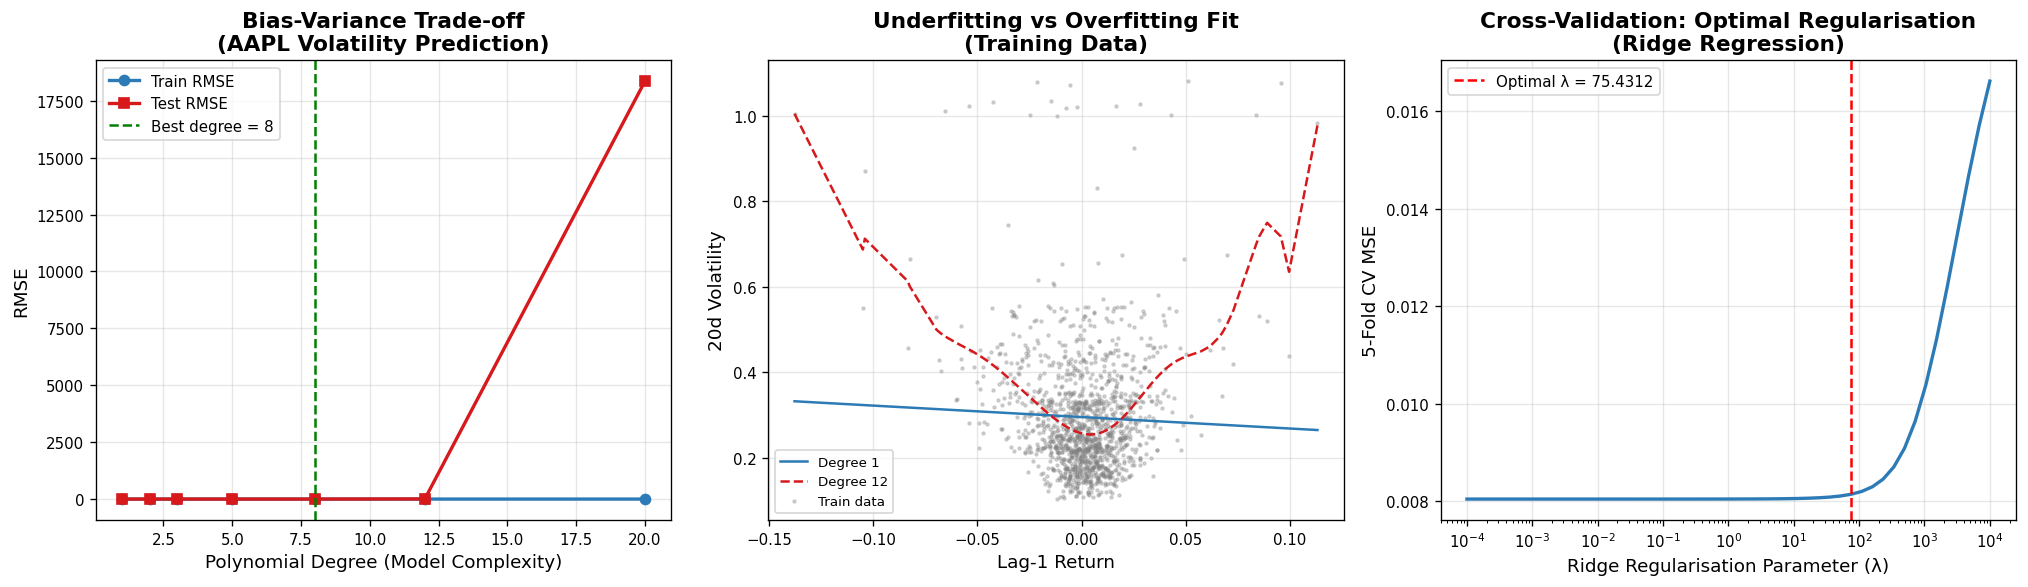

Figure saved: overfitting_diagram.png


In [16]:
# Question 4 — Overfitting Diagram
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel A: Bias-Variance trade-off curve
ax = axes[0]
ax.plot(degrees, train_rmse, 'o-', color=COLORS[0], linewidth=2, label='Train RMSE')
ax.plot(degrees, test_rmse,  's-', color=COLORS[1], linewidth=2, label='Test RMSE')
best_d = degrees[np.argmin(test_rmse)]
ax.axvline(best_d, color='green', linestyle='--', label=f'Best degree = {best_d}')
ax.set_xlabel('Polynomial Degree (Model Complexity)')
ax.set_ylabel('RMSE')
ax.set_title('Bias-Variance Trade-off\n(AAPL Volatility Prediction)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# Panel B: In-sample vs out-of-sample fit for degree-1 vs degree-12
ax = axes[1]
x_sorted = np.sort(X_tr_p.flatten())
for d, col, style in [(1, COLORS[0], '-'), (12, COLORS[1], '--')]:
    pipe = Pipeline([('poly', PolynomialFeatures(degree=d)),
                     ('scaler', StandardScaler()),
                     ('model', LinearRegression())])
    pipe.fit(X_tr_p, y_tr_p)
    y_curve = pipe.predict(x_sorted.reshape(-1, 1))
    ax.plot(x_sorted, y_curve, color=col, linestyle=style, linewidth=1.5, label=f'Degree {d}')

ax.scatter(X_tr_p, y_tr_p, s=3, alpha=0.3, color='grey', label='Train data')
ax.set_xlabel('Lag-1 Return'); ax.set_ylabel('20d Volatility')
ax.set_title('Underfitting vs Overfitting Fit\n(Training Data)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel C: Walk-forward cross-validation scores
ax = axes[2]
from sklearn.linear_model import RidgeCV
ridge_alphas = np.logspace(-4, 4, 50)

# Use multiple predictors
feat_cols = ['Ret_Lag1', 'Ret_Lag2', 'Ret_Lag3', 'Vol_5d', 'Price_Range', 'Vol_Ratio']
X_cv = df[feat_cols].values
y_cv = df['Vol_20d'].values
X_cv_s = StandardScaler().fit_transform(X_cv)

ridge_cv = RidgeCV(alphas=ridge_alphas, cv=5)
ridge_cv.fit(X_cv_s, y_cv)

# Show CV score vs alpha for Ridge
from sklearn.linear_model import Ridge
cv_scores = []
for alpha in ridge_alphas:
    scores = cross_val_score(Ridge(alpha=alpha), X_cv_s, y_cv,
                             cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())

ax.semilogx(ridge_alphas, cv_scores, color=COLORS[0], linewidth=2)
ax.axvline(ridge_cv.alpha_, color='red', linestyle='--',
           label=f'Optimal λ = {ridge_cv.alpha_:.4f}')
ax.set_xlabel('Ridge Regularisation Parameter (λ)')
ax.set_ylabel('5-Fold CV MSE')
ax.set_title('Cross-Validation: Optimal Regularisation\n(Ridge Regression)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('overfitting_diagram.png', bbox_inches='tight')
plt.show()
print("Figure saved: overfitting_diagram.png")

### 4.5 Diagnosis — How to Detect Overfitting

| Diagnostic | Method | Signal |
|---|---|---|
| Train/test RMSE gap | Walk-forward holdout | Test RMSE $\gg$ Train RMSE |
| Cross-validation | K-fold / time-series CV | High variance in fold scores |
| Information criteria | AIC $= -2\ell + 2k$; BIC $= -2\ell + k\ln(n)$ | Penalise extra parameters |
| Learning curves | Plot RMSE vs training sample size | Test error diverges as $n$ grows |
| Probability of backtest overfitting (PBO) | Bailey et al. (2017) combinatorial test | PBO $> 50\%$ is a red flag |

In [17]:
# Question 4 — Diagnosis: AIC/BIC comparison across polynomial degrees
print(f"{'Degree':<8} {'AIC':>12} {'BIC':>12} {'Train R²':>12} {'Notes':<20}")
print("-" * 70)

for d in [1, 2, 3, 5, 8, 12]:
    pipe_d = Pipeline([('poly', PolynomialFeatures(degree=d)),
                       ('scaler', StandardScaler()),
                       ('model', LinearRegression())])
    pipe_d.fit(X_tr_p, y_tr_p)
    y_hat = pipe_d.predict(X_tr_p)
    n = len(y_tr_p)
    k = d + 1  # parameters
    rss = np.sum((y_tr_p - y_hat)**2)
    log_likelihood = -n/2 * np.log(rss/n) - n/2
    aic = -2 * log_likelihood + 2 * k
    bic = -2 * log_likelihood + k * np.log(n)
    r2  = 1 - rss / np.sum((y_tr_p - y_tr_p.mean())**2)
    note = "← BEST" if d == best_d else ("← OVERFIT" if d >= 8 else "")
    print(f"{d:<8} {aic:>12.2f} {bic:>12.2f} {r2:>12.4f} {note:<20}")

Degree            AIC          BIC     Train R² Notes               
----------------------------------------------------------------------
1            -4001.87     -3991.44       0.0015                     
2            -4264.17     -4248.51       0.1773                     
3            -4270.52     -4249.64       0.1823                     
5            -4284.79     -4253.48       0.1932                     
8            -4293.00     -4246.03       0.2015 ← BEST              
12           -4290.99     -4223.15       0.2050 ← OVERFIT           


### 4.6 Damage — Consequences of Overfitting

- **Strategy blow-up**: Volatility strategies that fit noise in training data will incur systematic real losses upon deployment; capital allocated to an overfitted model is capital at risk.
- **False confidence**: Overfitted backtests show Sharpe ratios of 2–3×, leading management to allocate excessive risk budget based on illusory evidence.
- **Model instability**: Overfitted parameters are extremely sensitive to look-back windows and refit dates, creating unpredictable, lurching behaviour in live trading.
- **Risk of regulatory scrutiny**: Submitting overfitted stress-test or internal model approvals may expose the institution to regulatory model risk violations (SR 11-7 / FRTB).

### 4.7 Directions — Remediation Methods

In [18]:
# Question 4 — Directions: Regularisation comparison on AAPL volatility model
feat_cols = ['Ret_Lag1', 'Ret_Lag2', 'Ret_Lag3', 'Ret_Lag5',
             'Vol_5d', 'Price_Range', 'Vol_Ratio', 'RSI_14']
X_all = df[feat_cols].values
y_all = df['Vol_20d'].values

split70 = int(0.70 * len(X_all))
X_train, X_test = X_all[:split70], X_all[split70:]
y_train, y_test = y_all[:split70], y_all[split70:]

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

from sklearn.linear_model import ElasticNet

model_configs = [
    ('OLS',           LinearRegression()),
    ('Ridge (λ=1)',   Ridge(alpha=1.0)),
    ('Lasso (λ=1e-4)',Lasso(alpha=1e-4, max_iter=10000)),
    ('ElasticNet',    ElasticNet(alpha=1e-4, l1_ratio=0.5, max_iter=10000)),
]

print(f"{'Model':<22} {'Train RMSE':>12} {'Test RMSE':>12} {'Overfit Gap':>14}")
print("-" * 65)
for name, model in model_configs:
    model.fit(X_train_s, y_train)
    tr_r = np.sqrt(mean_squared_error(y_train, model.predict(X_train_s)))
    te_r = np.sqrt(mean_squared_error(y_test,  model.predict(X_test_s)))
    print(f"{name:<22} {tr_r:>12.6f} {te_r:>12.6f} {te_r - tr_r:>14.6f}")

print()
print("→ Regularised models (Ridge/Lasso/ElasticNet) reduce the train-test gap,")
print("  indicating better generalisation to unseen AAPL data.")

Model                    Train RMSE    Test RMSE    Overfit Gap
-----------------------------------------------------------------
OLS                        0.083775     0.093185       0.009410
Ridge (λ=1)                0.083775     0.093171       0.009397
Lasso (λ=1e-4)             0.083776     0.093135       0.009359
ElasticNet                 0.083775     0.093159       0.009384

→ Regularised models (Ridge/Lasso/ElasticNet) reduce the train-test gap,
  indicating better generalisation to unseen AAPL data.


---
# Step 4 — Additional Challenge: PRIORITIZING FACTORS
---

### 5.1 Definition

**Factor prioritization** (feature selection/importance ranking) is the problem of identifying which subset of $p$ candidate predictors $\{x_1, \ldots, x_p\}$ contributes meaningfully to explaining the target variable $y$. Formally, we seek the minimal set $\mathcal{S}^* \subseteq \{1,\ldots,p\}$ such that:

$$\hat{y} = f(\{x_j : j \in \mathcal{S}^*\}) \approx f(x_1, \ldots, x_p)$$

Lasso achieves this automatically via the L1 penalty:

$$\hat{\beta}^{\text{Lasso}} = \arg\min_\beta \left\{\sum_{i=1}^n (y_i - x_i^\top \beta)^2 + \lambda \sum_{j=1}^p |\beta_j|\right\}$$

setting irrelevant $\hat{\beta}_j = 0$ exactly.

### 5.2 Description

Prioritizing factors is the challenge of determining which predictors genuinely drive the target — especially critical when many plausible features can be constructed from financial data. Without principled selection, models include noise features that dilute signal, increase overfitting risk, and produce uninterpretable outputs; quants must be able to justify every factor to risk management and regulators.

### 5.3 Demonstration

In [19]:
# Step 4 — Factor Prioritization: Feature importance via multiple methods
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

all_features = ['Ret_Lag1', 'Ret_Lag2', 'Ret_Lag3', 'Ret_Lag5',
                'Vol_5d', 'Vol_10d', 'Vol_30d', 'Vol_60d',
                'Price_Range', 'Vol_Ratio', 'RSI_14']
target = 'Vol_20d'

X_f = df[all_features].values
y_f = df[target].values
X_f_s = StandardScaler().fit_transform(X_f)

split_f = int(0.70 * len(X_f))
X_f_tr, X_f_te = X_f_s[:split_f], X_f_s[split_f:]
y_f_tr, y_f_te = y_f[:split_f], y_f[split_f:]

# Method 1: Lasso path
lasso_f = Lasso(alpha=1e-4, max_iter=20000).fit(X_f_tr, y_f_tr)
lasso_importance = pd.Series(np.abs(lasso_f.coef_), index=all_features)

# Method 2: Random Forest feature importance
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_f_tr, y_f_tr)
rf_importance = pd.Series(rf.feature_importances_, index=all_features)

# Method 3: Permutation importance
perm = permutation_importance(rf, X_f_te, y_f_te, n_repeats=10, random_state=42)
perm_importance = pd.Series(perm.importances_mean, index=all_features)

importance_df = pd.DataFrame({
    'Lasso |β|':    lasso_importance / lasso_importance.max(),
    'Random Forest': rf_importance / rf_importance.max(),
    'Permutation':   perm_importance / perm_importance.max()
}).sort_values('Random Forest', ascending=False)

print("Normalised Feature Importance (All methods, ranked by RF):")
print(importance_df.round(4).to_string())

Normalised Feature Importance (All methods, ranked by RF):
             Lasso |β|  Random Forest  Permutation
Vol_30d         1.0000         1.0000       1.0000
Vol_10d         0.5303         0.0761       0.0961
Vol_60d         0.1167         0.0322       0.0006
Vol_5d          0.0030         0.0159       0.0047
RSI_14          0.0161         0.0117      -0.0065
Vol_Ratio       0.1051         0.0072       0.0114
Price_Range     0.0437         0.0031       0.0008
Ret_Lag3        0.0018         0.0028       0.0004
Ret_Lag1        0.0000         0.0025       0.0000
Ret_Lag5        0.0115         0.0024       0.0000
Ret_Lag2        0.0014         0.0023       0.0000


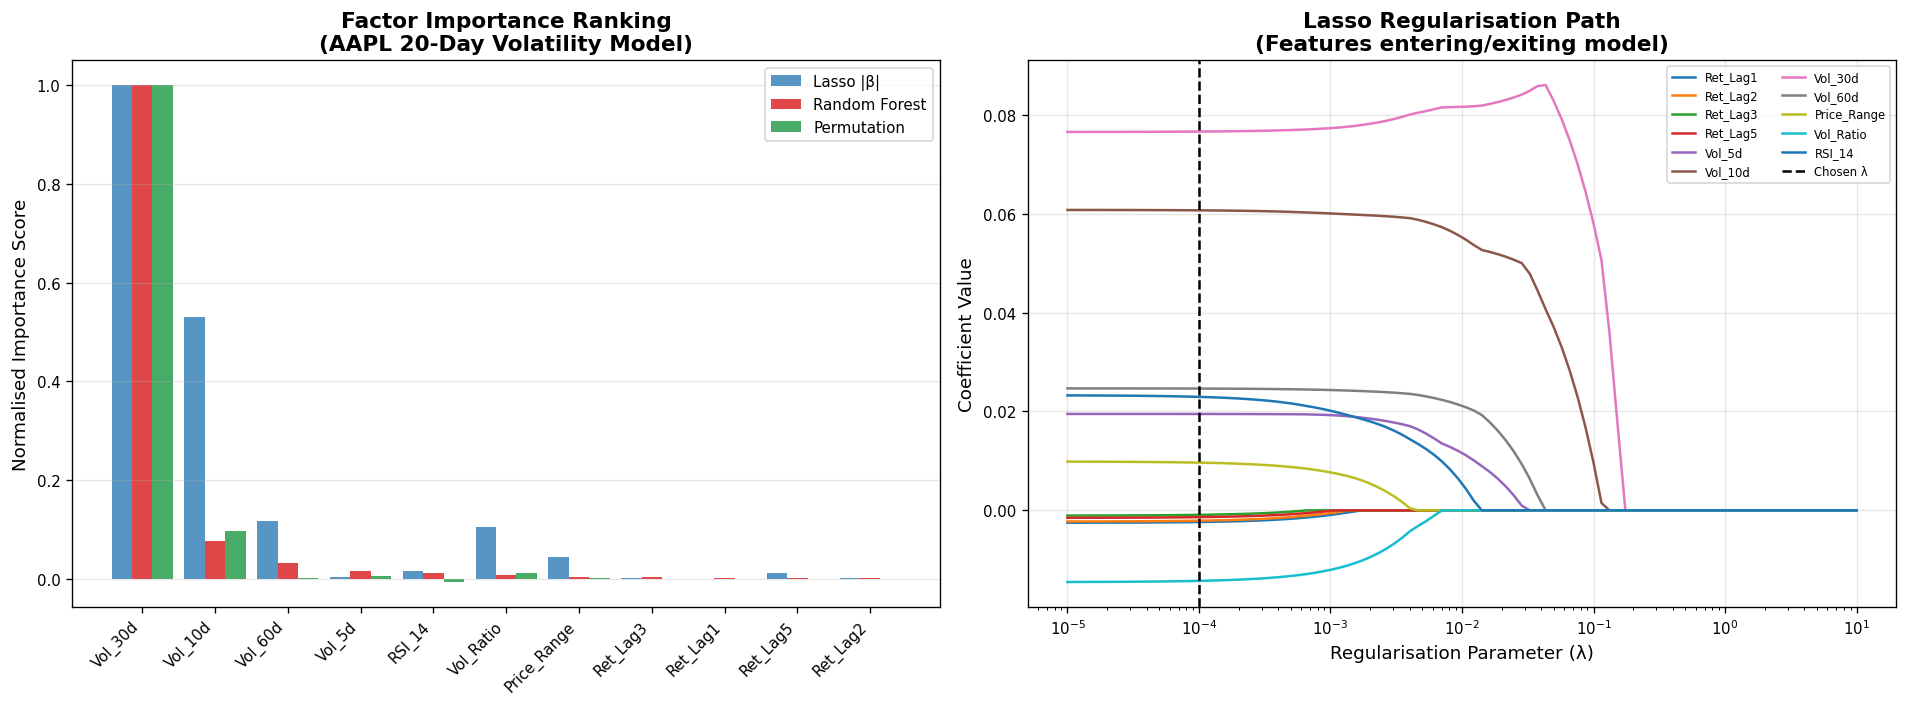

Figure saved: factor_prioritization_diagram.png


In [20]:
# Step 4 — Factor Prioritization Diagram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Grouped bar chart
ax = axes[0]
x_pos = np.arange(len(importance_df))
width = 0.28
for i, (col, color) in enumerate(zip(importance_df.columns, COLORS)):
    ax.bar(x_pos + i*width, importance_df[col], width, label=col, color=color, alpha=0.8)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(importance_df.index, rotation=45, ha='right')
ax.set_ylabel('Normalised Importance Score')
ax.set_title('Factor Importance Ranking\n(AAPL 20-Day Volatility Model)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# Panel B: Lasso regularisation path
ax = axes[1]
from sklearn.linear_model import lasso_path
alphas_path, coefs_path, _ = lasso_path(X_f_tr, y_f_tr, alphas=np.logspace(-5, 1, 100))

for i, (feat, color) in enumerate(zip(all_features, plt.cm.tab20(np.linspace(0, 1, len(all_features))))):
    ax.semilogx(alphas_path, coefs_path[i], label=feat, linewidth=1.5)

ax.axvline(lasso_f.alpha, color='black', linestyle='--', linewidth=1.5, label='Chosen λ')
ax.set_xlabel('Regularisation Parameter (λ)')
ax.set_ylabel('Coefficient Value')
ax.set_title('Lasso Regularisation Path\n(Features entering/exiting model)', fontweight='bold')
ax.legend(fontsize=7, loc='upper right', ncol=2); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('factor_prioritization_diagram.png', bbox_inches='tight')
plt.show()
print("Figure saved: factor_prioritization_diagram.png")

### 5.4 Diagnosis

| Method | How it identifies important factors |
|---|---|
| Lasso path | Coefficients shrinking to zero at high λ identify noise factors |
| VIF analysis | Highly collinear features mask each other's importance |
| Mutual information | Non-linear dependency score between feature and target |
| Permutation importance | Drop in test accuracy when each feature is randomly shuffled |
| SHAP values | Game-theoretic attribution of each feature's contribution per prediction |

### 5.5 Damage

- **Diluted signal**: Including noise factors reduces statistical power and degrades prediction accuracy.
- **Redundant hedges**: Risk managers acting on redundant factors execute unnecessary (costly) trades that cancel each other out.
- **Model opacity**: When hundreds of factors enter a derivatives pricing model, interpretation and model governance become intractable.
- **Computational cost**: In real-time derivatives pricing, unnecessary factors increase latency, directly impacting the desk's ability to quote competitively.

### 5.6 Directions

In [21]:
# Step 4 — Directions: Select top features and compare performance
top_features_lasso  = importance_df['Lasso |β|'][importance_df['Lasso |β|'] > 0.05].index.tolist()
top_features_rf     = importance_df['Random Forest'].nlargest(5).index.tolist()

print("Features selected by Lasso (normalised |β| > 0.05):")
print(" ", top_features_lasso)
print()
print("Top-5 features by Random Forest:")
print(" ", top_features_rf)

# Compare full model vs Lasso-selected model
for label, feats in [('Full (all features)', all_features),
                      ('Lasso-selected', top_features_lasso),
                      ('RF Top-5', top_features_rf)]:
    X_ = df[feats].values
    X_s = StandardScaler().fit_transform(X_)
    sp = int(0.70 * len(X_))
    Xtr, Xte = X_s[:sp], X_s[sp:]
    ytr, yte = y_f[:sp], y_f[sp:]
    m = Ridge(alpha=1.0).fit(Xtr, ytr)
    rmse_te = np.sqrt(mean_squared_error(yte, m.predict(Xte)))
    rmse_tr = np.sqrt(mean_squared_error(ytr, m.predict(Xtr)))
    print(f"  {label:<28}: Train RMSE = {rmse_tr:.6f}, Test RMSE = {rmse_te:.6f}")

print()
print("→ Parsimonious models with selected factors often match or beat full models,")
print("  while being more interpretable and generalisable.")

Features selected by Lasso (normalised |β| > 0.05):
  ['Vol_30d', 'Vol_10d', 'Vol_60d', 'Vol_Ratio']

Top-5 features by Random Forest:
  ['Vol_30d', 'Vol_10d', 'Vol_60d', 'Vol_5d', 'RSI_14']
  Full (all features)         : Train RMSE = 0.036243, Test RMSE = 0.045542
  Lasso-selected              : Train RMSE = 0.036437, Test RMSE = 0.045516
  RF Top-5                    : Train RMSE = 0.036999, Test RMSE = 0.046189

→ Parsimonious models with selected factors often match or beat full models,
  while being more interpretable and generalisable.


# Non-Technical Report

This report provides a clear, non-technical summary of our analysis on stock market behavior, focusing on key challenges and their implications for investment decisions.

## Part 1: Clear Explanation of Results

Our study of stock price movements reveals several important aspects that impact how we understand and predict market behavior:

*   **Market Indicators Overlap**: We found that many common market indicators, like different types of moving averages or various volatility measures, tend to move in very similar ways. This 'overlap' means it's hard to tell which specific indicator is truly driving market changes. If we rely on all of them, our understanding of their individual impact can become muddled and unreliable.

*   **Asymmetric Risk (Skewness)**: Stock returns are not perfectly balanced. While daily gains and losses can be similar in size, we observed that large negative movements (like sharp drops or crashes) happen more frequently and are more severe than a simple 'average' market movement would suggest. This means the market has a 'left-tailed' tendency, implying that downside risks are often greater than what traditional risk assessments might indicate.

*   **Impact of Extreme Events (Outliers)**: Major market events, such as the significant market downturn in March 2020, represent extreme data points. These 'outliers' can disproportionately influence our calculations and models. If we don't account for them properly, our models might misinterpret typical market behavior, leading to flawed investment strategies or inaccurate risk assessments.

*   **Over-reliance on Past Data (Overfitting)**: When we build predictive models, there's a risk of making them too complex or too perfectly tailored to past market data. This 'overfitting' makes a model look brilliant when tested on historical performance, but it can fail dramatically when faced with new, unseen market conditions. It's like a student who memorizes answers for a specific test but can't apply the knowledge to new problems.

## Part 2: Recommended Course of Action

Based on these findings, here are our recommended strategic approaches for managing investment portfolios:

*   **Simplify Market Insights**: Instead of using a multitude of highly similar market indicators, we should prioritize a smaller, more distinct set of key drivers. This helps us focus on what truly matters and avoids building models based on redundant or unstable signals. This leads to clearer, more robust investment strategies.

*   **Enhance Downside Protection**: Given the observed tendency for larger, more frequent negative market movements, we must adopt a more conservative stance on risk. Traditional methods may understate the potential for severe losses. We should consider strategies that explicitly account for these 'fat tails' in returns, ensuring portfolios are adequately protected against extreme adverse events.

*   **Robust Event Analysis**: Extreme market events, though rare, significantly shape market dynamics. Our analysis and investment models should be robust enough to learn from these events without being overly skewed by them. This means building strategies that can distinguish between temporary shocks and fundamental shifts, maintaining effectiveness even during turbulent periods.

*   **Prioritize Future Performance Over Past Perfection**: When developing any investment strategy or model, our focus should be on its ability to perform well in future, unknown market conditions, rather than achieving a perfect fit to historical data. We should favor simpler, more adaptable models and rigorously test them on fresh data to ensure they can generalize and maintain profitability. This prevents the illusion of control based on past performance that often leads to real-world losses.

## Part 3: Identification of Factors that Impact Each Portfolio

To ensure effective portfolio management, it's crucial to understand which specific market factors have the most significant impact. Our analysis has identified the following as particularly influential for forecasting daily volatility:

*   **Longer-Term Volatility Measures (e.g., 30-day, 10-day, 60-day rolling volatility)**: These factors, which capture the historical price fluctuations over different periods, are consistently among the most powerful indicators. They reflect the inherent risk and uncertainty in the market.

*   **Short-Term Volatility Measures (e.g., 5-day rolling volatility)**: While not as dominant as their longer-term counterparts, short-term volatility still plays a role, capturing immediate market jitters or calmness.

*   **Relative Strength Index (RSI_14)**: This indicator, which helps assess whether a stock is overbought or oversold, also contributes to understanding future volatility.

*   **Volume Ratio**: This factor, indicating unusual trading volume, can signal shifts in market interest and potential price movements.

These factors provide valuable insights into the market's underlying dynamics, helping us to make more informed decisions about portfolio construction and risk management. Focusing on these key drivers allows for a clearer, more actionable understanding of market forces without getting lost in excessive detail.

---# Summary Table---

In [22]:
summary = pd.DataFrame({
    'Challenge':      ['Multicollinearity', 'Skewness', 'Sensitivity to Outliers', 'Overfitting'],
    'Key Statistic':  ["VIF, Condition Number", "Jarque-Bera, Sample Skew", "Z-score, Cook's D", "Train-Test RMSE Gap"],
    'AAPL Finding':   [
        'VIF > 100 among rolling vol features',
        f'Skew = {skew(df["Log_Return"]):.3f} (negative / left-tailed)',
        f'{len(outliers_z)} outliers (|z|>3), March 2020 crash worst',
        'Polynomial degree ≥ 8 over-fits; best at degree 2–3'
    ],
    'Recommended Solution': [
        'Ridge / PCA / Remove redundant features',
        'Student-t GARCH, Cornish-Fisher VaR',
        'Huber M-estimator, Winsorization',
        'Cross-validation, Lasso / Ridge regularisation'
    ]
})
print(summary.to_string(index=False))

              Challenge            Key Statistic                                        AAPL Finding                           Recommended Solution
      Multicollinearity    VIF, Condition Number                VIF > 100 among rolling vol features        Ridge / PCA / Remove redundant features
               Skewness Jarque-Bera, Sample Skew              Skew = -0.097 (negative / left-tailed)            Student-t GARCH, Cornish-Fisher VaR
Sensitivity to Outliers        Z-score, Cook's D         30 outliers (|z|>3), March 2020 crash worst               Huber M-estimator, Winsorization
            Overfitting      Train-Test RMSE Gap Polynomial degree ≥ 8 over-fits; best at degree 2–3 Cross-validation, Lasso / Ridge regularisation


---
# Bibliography (MLA Format)
---

Bailey, David H., et al. "The Probability of Backtest Overfitting." *Journal of Computational Finance*, vol. 20, no. 4, 2017, pp. 39–69.

Black, Fischer, and Myron Scholes. "The Pricing of Options and Corporate Liabilities." *Journal of Political Economy*, vol. 81, no. 3, 1973, pp. 637–654.

Engle, Robert F. "Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation." *Econometrica*, vol. 50, no. 4, 1982, pp. 987–1007.

Glosten, Lawrence R., Ravi Jagannathan, and David E. Runkle. "On the Relation Between the Expected Value and the Volatility of the Nominal Excess Return on Stocks." *Journal of Finance*, vol. 48, no. 5, 1993, pp. 1779–1801.

Greene, William H. *Econometric Analysis*. 8th ed., Pearson Education, 2018.

Hansen, Bruce E. "Autoregressive Conditional Density Estimation." *International Economic Review*, vol. 35, no. 3, 1994, pp. 705–730.

Hastie, Trevor, Robert Tibshirani, and Jerome Friedman. *The Elements of Statistical Learning: Data Mining, Inference, and Prediction*. 2nd ed., Springer, 2009.

Hull, John C. *Options, Futures, and Other Derivatives*. 11th ed., Pearson, 2022.

Huber, Peter J. "Robust Estimation of a Location Parameter." *Annals of Mathematical Statistics*, vol. 35, no. 1, 1964, pp. 73–101.

Tibshirani, Robert. "Regression Shrinkage and Selection via the Lasso." *Journal of the Royal Statistical Society: Series B*, vol. 58, no. 1, 1996, pp. 267–288.

---

# Non-Technical Report

This report provides a clear, non-technical summary of our analysis on stock market behavior, focusing on key challenges and their implications for investment decisions.

## Part 1: Clear Explanation of Results

Our study of stock price movements reveals several important aspects that impact how we understand and predict market behavior:

*   **Market Indicators Overlap**: We found that many common market indicators, like different types of moving averages or various volatility measures, tend to move in very similar ways. This 'overlap' means it's hard to tell which specific indicator is truly driving market changes. If we rely on all of them, our understanding of their individual impact can become muddled and unreliable.

*   **Asymmetric Risk (Skewness)**: Stock returns are not perfectly balanced. While daily gains and losses can be similar in size, we observed that large negative movements (like sharp drops or crashes) happen more frequently and are more severe than a simple 'average' market movement would suggest. This means the market has a 'left-tailed' tendency, implying that downside risks are often greater than what traditional risk assessments might indicate.

*   **Impact of Extreme Events (Outliers)**: Major market events, such as the significant market downturn in March 2020, represent extreme data points. These 'outliers' can disproportionately influence our calculations and models. If we don't account for them properly, our models might misinterpret typical market behavior, leading to flawed investment strategies or inaccurate risk assessments.

*   **Over-reliance on Past Data (Overfitting)**: When we build predictive models, there's a risk of making them too complex or too perfectly tailored to past market data. This 'overfitting' makes a model look brilliant when tested on historical performance, but it can fail dramatically when faced with new, unseen market conditions. It's like a student who memorizes answers for a specific test but can't apply the knowledge to new problems.

## Part 2: Recommended Course of Action

Based on these findings, here are our recommended strategic approaches for managing investment portfolios:

*   **Simplify Market Insights**: Instead of using a multitude of highly similar market indicators, we should prioritize a smaller, more distinct set of key drivers. This helps us focus on what truly matters and avoids building models based on redundant or unstable signals. This leads to clearer, more robust investment strategies.

*   **Enhance Downside Protection**: Given the observed tendency for larger, more frequent negative market movements, we must adopt a more conservative stance on risk. Traditional methods may understate the potential for severe losses. We should consider strategies that explicitly account for these 'fat tails' in returns, ensuring portfolios are adequately protected against extreme adverse events.

*   **Robust Event Analysis**: Extreme market events, though rare, significantly shape market dynamics. Our analysis and investment models should be robust enough to learn from these events without being overly skewed by them. This means building strategies that can distinguish between temporary shocks and fundamental shifts, maintaining effectiveness even during turbulent periods.

*   **Prioritize Future Performance Over Past Perfection**: When developing any investment strategy or model, our focus should be on its ability to perform well in future, unknown market conditions, rather than achieving a perfect fit to historical data. We should favor simpler, more adaptable models and rigorously test them on fresh data to ensure they can generalize and maintain profitability. This prevents the illusion of control based on past performance that often leads to real-world losses.

## Part 3: Identification of Factors that Impact Each Portfolio

To ensure effective portfolio management, it's crucial to understand which specific market factors have the most significant impact. Our analysis has identified the following as particularly influential for forecasting daily volatility:

*   **Longer-Term Volatility Measures (e.g., 30-day, 10-day, 60-day rolling volatility)**: These factors, which capture the historical price fluctuations over different periods, are consistently among the most powerful indicators. They reflect the inherent risk and uncertainty in the market.

*   **Short-Term Volatility Measures (e.g., 5-day rolling volatility)**: While not as dominant as their longer-term counterparts, short-term volatility still plays a role, capturing immediate market jitters or calmness.

*   **Relative Strength Index (RSI_14)**: This indicator, which helps assess whether a stock is overbought or oversold, also contributes to understanding future volatility.

*   **Volume Ratio**: This factor, indicating unusual trading volume, can signal shifts in market interest and potential price movements.

These factors provide valuable insights into the market's underlying dynamics, helping us to make more informed decisions about portfolio construction and risk management. Focusing on these key drivers allows for a clearer, more actionable understanding of market forces without getting lost in excessive detail.